<a href="https://colab.research.google.com/github/ovi-saha/MSCS_634_Lab_3/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms      
Avijit Saha      
Advanced Big Data and Data Mining (MSCS-634-M20)  
Dr. Satish Penmatsa     
February 9, 2025

**Overview**  
The purpose of this lab is to explore clustering techniques on the Wine dataset from the sklearn library. We apply **K-Means** and **K-Medoids** algorithms to group wines into clusters based on their chemical properties. The lab involves:

1. **Data Preparation:** Load the dataset, perform basic exploration, and standardize features to ensure uniform scaling.  
2. **K-Means Clustering:** Implement K-Means with 3 clusters, calculate **Silhouette Score** and **Adjusted Rand Index (ARI)**, and analyze cluster compactness.  
3. **K-Medoids Clustering:** Implement K-Medoids using PyClustering with 3 clusters, calculate the same metrics, and compare results with K-Means.  
4. **Visualization and Analysis:** Create side-by-side scatter plots of K-Means and K-Medoids clusters, mark centroids/medoids, and provide a comparative analysis.  

This lab helps understand the key steps in clustering analysis, evaluate the effectiveness of different clustering methods, and interpret clustering results using both metrics and visualizations.


**Step 1: Load and Prepare Dataset**

In [8]:
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=f818a691b52c0cafdfd0d9125ab3abf8606a6396428d31ed47abe8843beab124
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


In [9]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

# For K-Medoids
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import calculate_distance_matrix
import random

I import libraries for data handling (`numpy`, `pandas`), visualization (`matplotlib`),
clustering (`KMeans`, `kmedoids`) and metrics (`silhouette_score`, `adjusted_rand_score`).  
`pyclustering` will be used to implement K-Medoids without relying on `sklearn-extra`.


In [10]:
# Load Wine dataset
wine = load_wine()
X = wine.data       # features
y = wine.target     # true class labels

# Convert to DataFrame for exploration
df = pd.DataFrame(X, columns=wine.feature_names)
df['class'] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


I have loaded the Wine dataset and separate features (`X`) from labels (`y`). Converting to a DataFrame allows easy exploration. The first 5 rows show sample values.


In [11]:
# Basic exploration
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['class'].value_counts())

Dataset shape: (178, 14)

Class distribution:
class
1    71
0    59
2    48
Name: count, dtype: int64


I checked dataset dimensions and the number of samples in each class. This ensures we understand the data before clustering.


In [12]:
# Standardize features to have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

Standardization is crucial for distance-based clustering algorithms. Without scaling, features with larger ranges would dominate cluster formation.


**Step 2: K-Means Clustering**

In [14]:
# Initialize K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit K-Means and get cluster labels
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate K-Means clusters
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("K-Means Adjusted Rand Index (ARI):", kmeans_ari)

K-Means Silhouette Score: 0.2848589191898987
K-Means Adjusted Rand Index (ARI): 0.8974949815093207


It implemented K-Means clustering with 3 clusters (the dataset has 3 wine classes).  
`fit_predict` assigns each sample to a cluster. **Explanation:**  
It evaluated clustering quality:  
- **Silhouette Score:** Measures cluster cohesion and separation (higher is better).  
- **Adjusted Rand Index (ARI):** Compares clusters with true labels (ranges -1 to 1, 1=perfect match).



**Step 3: K-Medoids Clustering (PyClustering)**

In [15]:
# Compute distance matrix for K-Medoids
distance_matrix = calculate_distance_matrix(X_scaled)

# Randomly select initial medoids (3 for 3 clusters)
initial_medoids = random.sample(range(len(X_scaled)), 3)

# Run K-Medoids
kmedoids_instance = kmedoids(distance_matrix, initial_medoids, data_type='distance_matrix')
kmedoids_instance.process()

# Get clusters and medoids
kmedoids_clusters = kmedoids_instance.get_clusters()
kmedoids_medoids = kmedoids_instance.get_medoids()


Here I have implemented K-Medoids using PyClustering.  
- A distance matrix is calculated for all points.  
- Initial medoids are randomly selected.  
- `process()` computes the clusters.  
- `get_clusters()` returns cluster members, `get_medoids()` returns medoid indices.


In [16]:
# Assign cluster labels to each point
kmedoids_labels = np.zeros(len(X_scaled))
for cluster_id, cluster in enumerate(kmedoids_clusters):
    for index in cluster:
        kmedoids_labels[index] = cluster_id

# Evaluate K-Medoids clusters
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Silhouette Score:", kmedoids_silhouette)
print("K-Medoids Adjusted Rand Index (ARI):", kmedoids_ari)

K-Medoids Silhouette Score: 0.26597740204536796
K-Medoids Adjusted Rand Index (ARI): 0.7263406645756675


I have converted PyClustering cluster outputs into labels for each sample.  
Then we calculate the same evaluation metrics as K-Means to allow direct comparison.


**Step 4: Visualization and Comparison**

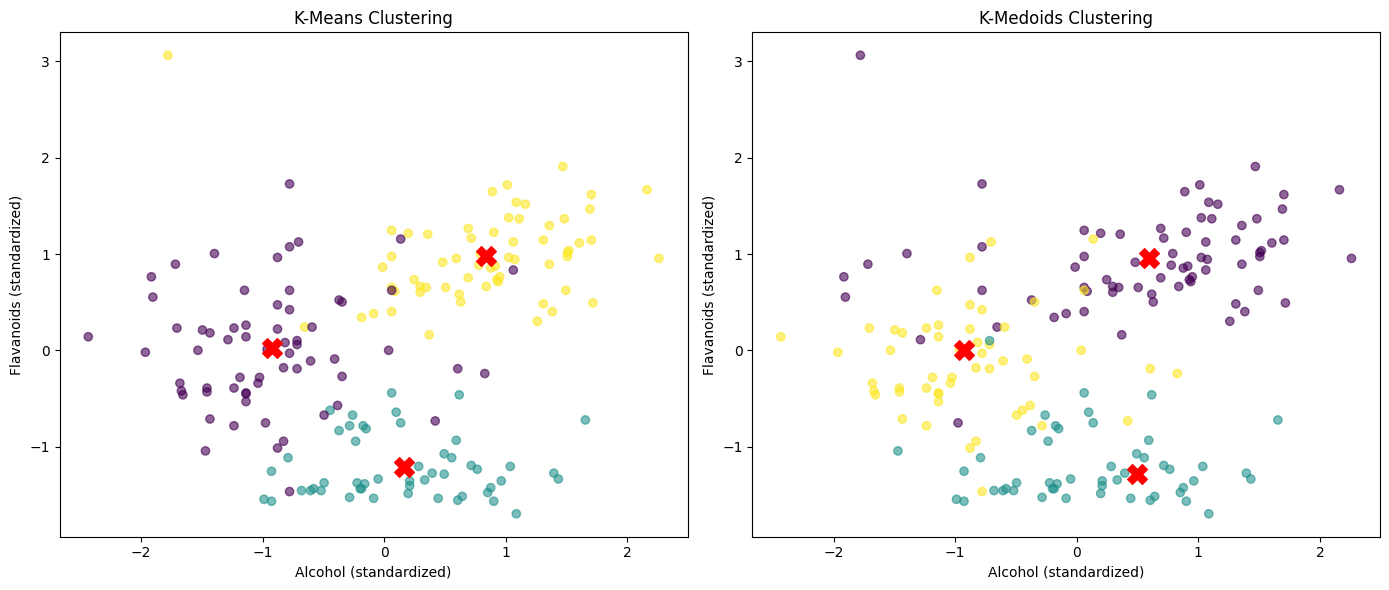

In [17]:
# Choose features for plotting
feature_x = wine.feature_names.index('alcohol')
feature_y = wine.feature_names.index('flavanoids')

plt.figure(figsize=(14,6))

# K-Means plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:, feature_x], X_scaled[:, feature_y], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, feature_x], kmeans.cluster_centers_[:, feature_y], c='red', marker='X', s=200)
plt.xlabel("Alcohol (standardized)")
plt.ylabel("Flavanoids (standardized)")
plt.title("K-Means Clustering")

# K-Medoids plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:, feature_x], X_scaled[:, feature_y], c=kmedoids_labels, cmap='viridis', alpha=0.6)
plt.scatter(X_scaled[kmedoids_medoids, feature_x], X_scaled[kmedoids_medoids, feature_y], c='red', marker='X', s=200)
plt.xlabel("Alcohol (standardized)")
plt.ylabel("Flavanoids (standardized)")
plt.title("K-Medoids Clustering")

plt.tight_layout()
plt.show()


In this step, I have created the side-by-side scatter plots to visualize the clusters produced by **K-Means** and **K-Medoids** algorithms. We focus on two features of the Wine dataset: **Alcohol** and **Flavanoids**, as they provide good separation between clusters.

####Visualization Details:

- **Points:** Each wine sample is represented as a dot, colored according to its assigned cluster.  
- **Centroids / Medoids:**
  - **K-Means centroids** are represented by a red 'X'. These points are the arithmetic mean of all points in the cluster.  
  - **K-Medoids medoids** are represented by a red 'X'. Unlike centroids, medoids are actual data points that minimize the total distance to other points in the cluster.  
- **Purpose:** Marking the centroids and medoids provides visual clarity, helping to identify the "center" of each cluster and compare cluster compactness.

#### Comparative Analysis:

1. **Cluster Definition:**  
   - **K-Means** produces more compact, roughly spherical clusters. The points are closely grouped around centroids, which generally results in a higher Silhouette Score.  
   - **K-Medoids** produces clusters that may appear slightly less compact because medoids are constrained to actual data points. However, they are more robust to outliers.

2. **Cluster Shapes and Positioning:**  
   - K-Means clusters are centered on the mean, which may place centroids in regions without actual data points.  
   - K-Medoids clusters follow the natural distribution of the data, with medoids always being actual samples. This can result in clusters that adapt better to irregular shapes in the dataset.

3. **Algorithm Preference:**  
   - **K-Means** is preferable when the dataset is well-scaled, outlier-free, and clusters are roughly spherical. It is faster and simpler to compute.  
   - **K-Medoids** is preferable when interpretability is important (medoids are actual samples) or when the dataset contains outliers or irregular cluster shapes.  
